# **Gap-Filling Flux Tower Data with Machine Learning**

Every flux record has holes. This tutorial creates realistic gaps in a complete record, fills them two ways, and measures how well each method recovers the truth.

## **Learning objectives**

By the end of this tutorial you will be able to:

- Explain why flux data have gaps and why the gap pattern matters.
- Implement a lookup-table gap filler based on similar meteorological conditions (the idea behind the standard MDS method).
- Fill gaps with a random forest trained on the available data.
- Evaluate both methods on short and long artificial gaps and on annual sums.

**Before you start:** Notebook 08. Uses `scikit-learn`.

## **Why gaps, and why they matter**

Eddy-covariance systems fail in rain, at night when turbulence is weak, during power outages, and when sensors need
calibration. Typical records are 20 to 40% gaps at the half-hourly scale. To compute an annual water or carbon budget the
gaps must be filled, and the filling method becomes part of the measurement.

The standard method in FLUXNET, **marginal distribution sampling (MDS)**, fills a gap with the average flux from days
that had similar radiation, temperature, and vapor pressure deficit within a window around the gap. The idea is simple:
fluxes on similar days should be similar. We implement a daily version of that lookup and compare it with a
random forest that learns the relationship from all available data.

**The test.** We start from the complete gap-filled US-Var record, punch out artificial gaps of two kinds, fill them,
and compare with the values we removed. Short random gaps (1-3 days) mimic instrument dropouts; long gaps (2-6 weeks) mimic
a sensor failure. Long gaps are the hard case, because there are no nearby days to borrow from.

**Data:** US-Var (Vaira Ranch, California), daily 2000-2021: fluxes, meteorology, LAI, fPAR, GPP, soil moisture. See the process-hydrology tutorials for a description.

## **Setup: packages and data**

The cell below loads the packages we need and defines a small helper that finds the sample data. If you are running inside the cloned repository it uses the local `sample_data/` folder; on Google Colab it downloads the files from GitHub.

In [1]:
import os, urllib.request, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 100

BASE = "https://raw.githubusercontent.com/praghav444/CEE491-591-Process-Hydrology-Tutorials/main/sample_data/"

def get_data(fname):
    """Return a local path to a sample data file, downloading it from GitHub if needed."""
    for local in [os.path.join('..', '..', 'sample_data', fname), os.path.join('sample_data', fname)]:
        if os.path.exists(local):
            return local
    os.makedirs('sample_data', exist_ok=True)
    out = os.path.join('sample_data', fname)
    urllib.request.urlretrieve(BASE + fname, out)
    return out

files = ['daily_data_UA-Var_2000_2021.csv']
paths = {f: get_data(f) for f in files}
paths

{'daily_data_UA-Var_2000_2021.csv': '..\\..\\sample_data\\daily_data_UA-Var_2000_2021.csv'}

In [2]:
df = pd.read_csv(paths['daily_data_UA-Var_2000_2021.csv'])
df['Date'] = pd.to_datetime(df['DateTime']); df = df.set_index('Date').drop(columns='DateTime')
df = df.rename(columns={'LE_F_MDS': 'LE', 'H_F_MDS': 'H', 'G_F_MDS': 'G', 'NETRAD': 'Rn', 'TA_F': 'TA', 'VPD_F': 'VPD_hPa',
                        'SW_IN_F': 'SW_IN', 'WS_F': 'WS', 'PA_F': 'PA', 'LW_IN_F': 'LW_IN', 'theta_2': 'SM'})
df['VPD'] = df['VPD_hPa'] / 10.0
df['SM'] = df['SM'].interpolate(limit=10)
df['doy_sin'] = np.sin(2 * np.pi * df.index.dayofyear / 365.25); df['doy_cos'] = np.cos(2 * np.pi * df.index.dayofyear / 365.25)

data = df[['LE', 'SW_IN', 'TA', 'VPD', 'WS', 'Rn', 'SM', 'LAI', 'doy_sin', 'doy_cos']].dropna().loc['2005':'2015']
truth = data['LE'].copy()
rng = np.random.default_rng(42)
gap = pd.Series(False, index=data.index)
# short gaps: 150 gaps of 1-3 days
for start in rng.choice(len(data) - 3, 150, replace=False):
    gap.iloc[start:start + rng.integers(1, 4)] = True
# long gaps: 6 gaps of 14-42 days
for start in rng.choice(len(data) - 45, 6, replace=False):
    gap.iloc[start:start + rng.integers(14, 43)] = True
gap_kind = pd.Series('none', index=data.index)
runs = (gap != gap.shift()).cumsum()
for r_, g in gap.groupby(runs):
    if g.iloc[0]: gap_kind.loc[g.index] = 'short' if len(g) <= 3 else 'long'
le_gappy = truth.where(~gap)
print(f'Gaps: {gap.sum()} of {len(gap)} days ({100*gap.mean():.1f}%); short-gap days {(gap_kind=="short").sum()}, long-gap days {(gap_kind=="long").sum()}')

Gaps: 448 of 4017 days (11.2%); short-gap days 266, long-gap days 182


## **Step 1: Lookup-table filling (MDS-style)**

For each gap day, average LE over days within a $\pm$ window that have similar SW$_{in}$ (within 50 W m$^{-2}$), temperature (within 2.5 $^\circ$C), and VPD (within 0.5 kPa). If no similar day exists, widen the window.

In [3]:
def mds_fill(le, met, windows=(7, 14, 30, 60), tol=dict(SW_IN=50, TA=2.5, VPD=0.5)):
    filled = le.copy(); src = pd.Series('observed', index=le.index)
    idx = np.arange(len(le)); missing = np.where(le.isna())[0]
    for i in missing:
        done = False
        for w in windows:
            lo, hi = max(0, i - w), min(len(le), i + w + 1)
            cand = np.arange(lo, hi); cand = cand[~le.iloc[cand].isna().values]
            ok = np.ones(len(cand), bool)
            for v, t in tol.items():
                ok &= (np.abs(met[v].iloc[cand].values - met[v].iloc[i]) <= t)
            if ok.sum() >= 2:
                filled.iloc[i] = le.iloc[cand[ok]].mean(); src.iloc[i] = f'lookup {w}d'; done = True; break
        if not done:                                             # fallback: same-window mean regardless of met
            lo, hi = max(0, i - 60), min(len(le), i + 61)
            filled.iloc[i] = le.iloc[lo:hi].mean(); src.iloc[i] = 'window mean'
    return filled, src

le_mds, src = mds_fill(le_gappy, data)
print(src[gap].value_counts())

lookup 7d      256
lookup 14d      84
lookup 30d      80
lookup 60d      20
window mean      8
Name: count, dtype: int64


## **Step 2: Random forest filling**

Train on all non-gap days, predict the gap days. The features are the meteorological drivers plus a seasonal signal; soil moisture and LAI help with the long gaps.

In [4]:
feat = ['SW_IN', 'TA', 'VPD', 'WS', 'Rn', 'SM', 'LAI', 'doy_sin', 'doy_cos']
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=3, n_jobs=-1, random_state=0)
rf.fit(data.loc[~gap, feat], truth[~gap])
le_rf = le_gappy.copy(); le_rf[gap] = rf.predict(data.loc[gap, feat])

## **Step 3: How well did each method do?**

In [5]:
def score(pred, obs):
    e = pred - obs
    return pd.Series({'RMSE (W/m2)': np.sqrt(np.mean(e ** 2)), 'Bias (W/m2)': e.mean(), 'R2': np.corrcoef(pred, obs)[0, 1] ** 2})
rows = {}
for kind in ['short', 'long']:
    m = gap_kind == kind
    rows[('Lookup (MDS-style)', kind)] = score(le_mds[m], truth[m]); rows[('Random forest', kind)] = score(le_rf[m], truth[m])
print(pd.DataFrame(rows).T.round(2))

# effect on annual sums
lam = 2.45; to_mm = 86400 / (lam * 1e6)
ann = pd.DataFrame({'truth': truth, 'lookup': le_mds, 'random forest': le_rf}).resample('YE').sum() * to_mm
ann.index = ann.index.year; ann['lookup error (mm)'] = ann['lookup'] - ann['truth']; ann['RF error (mm)'] = ann['random forest'] - ann['truth']
print('\nAnnual ET (mm) and gap-filling error:'); print(ann.round(0))

                          RMSE (W/m2)  Bias (W/m2)    R2
Lookup (MDS-style) short         9.81         0.91  0.84
Random forest      short         6.48         0.02  0.93
Lookup (MDS-style) long         17.55         3.25  0.60
Random forest      long          9.46        -0.12  0.85

Annual ET (mm) and gap-filling error:
      truth  lookup  random forest  lookup error (mm)  RF error (mm)
Date                                                                
2005  388.0   385.0          381.0               -3.0           -7.0
2006  317.0   318.0          316.0                0.0           -1.0
2007  276.0   276.0          277.0                0.0            1.0
2008  236.0   236.0          236.0               -0.0           -0.0
2009  325.0   327.0          325.0                2.0            0.0
2010  348.0   356.0          338.0                8.0          -10.0
2011  337.0   346.0          329.0               10.0           -7.0
2012  292.0   292.0          292.0               -0.0  

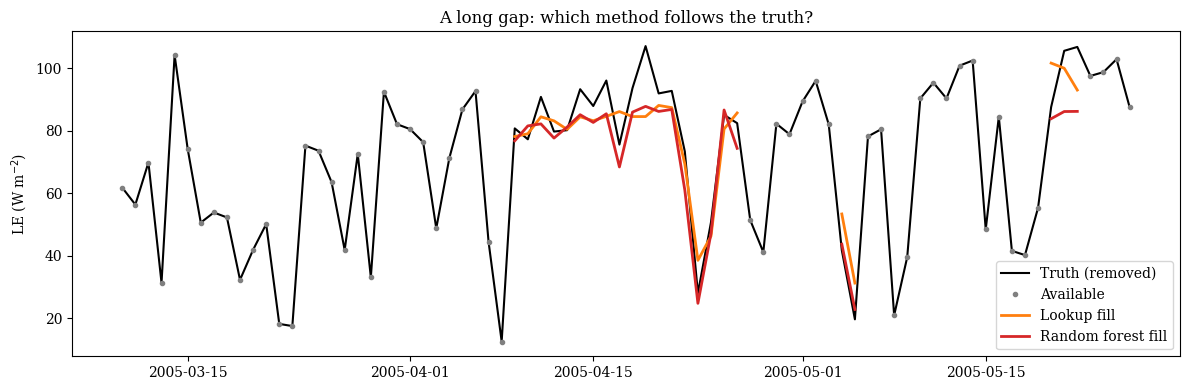

In [6]:
long_idx = gap_kind[gap_kind == 'long'].index
first_long = long_idx[0]; sl = slice(first_long - pd.Timedelta(days=30), long_idx[long_idx < first_long + pd.Timedelta(days=60)][-1] + pd.Timedelta(days=30))
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(truth.loc[sl].index, truth.loc[sl], 'k', label='Truth (removed)'); ax.plot(le_gappy.loc[sl].index, le_gappy.loc[sl], 'o', ms=3, color='grey', label='Available')
ax.plot(le_mds.loc[sl].index, le_mds.loc[sl].where(gap.loc[sl]), 'tab:orange', lw=2, label='Lookup fill'); ax.plot(le_rf.loc[sl].index, le_rf.loc[sl].where(gap.loc[sl]), 'tab:red', lw=2, label='Random forest fill')
ax.set_ylabel('LE (W m$^{-2}$)'); ax.legend(); ax.set_title('A long gap: which method follows the truth?'); plt.tight_layout()

**What to notice.** For short gaps both methods work, because neighboring days are informative. For long gaps the lookup
method drifts toward the window mean while the random forest, which has learned the seasonal and soil-moisture
controls from the whole record, stays closer. Annual sums are usually within a few percent either way, but the errors
are not random: a method that is biased during the growing season biases the annual budget.

## **Exercises**

**Exercise 1.** Increase the gap fraction to 40% by adding more short gaps. At what point does the random forest start to lose skill on the *short* gaps?

**Exercise 2.** Repeat the long-gap test with the random forest trained without `SM` and `LAI`. How much of its advantage on long gaps came from those variables?

**Exercise 3.** Fill the gaps with a simple seasonal climatology (mean LE for that day of year over the other years). Where does it beat the two methods, and where does it fail?

**Exercise 4.** Uncertainty: fill each gap 50 times with random forests trained on bootstrap samples of the training data, and report the spread of the annual ET as an uncertainty range.

## **References**

- Reichstein, M., et al. (2005). On the separation of net ecosystem exchange into assimilation and ecosystem respiration: review and improved algorithm. *Global Change Biology*, 11, 1424-1439.
- Moffat, A. M., et al. (2007). Comprehensive comparison of gap-filling techniques for eddy covariance net carbon fluxes. *Agricultural and Forest Meteorology*, 147, 209-232.
- Wutzler, T., et al. (2018). Basic and extensible post-processing of eddy covariance flux data with REddyProc. *Biogeosciences*, 15, 5015-5030.